In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.cm as cm
import matplotlib as mpl

def normalize(x, mu, std):
    # return x
    return (x - mu) / std

def create_data(chemprop_model_path, target_columns, scaler_dict, uncertainty_method="evidential_total",normalize_data=True):
    gold_data_path = os.path.join(chemprop_model_path, "test_full.csv")
    pred_data_path = os.path.join(chemprop_model_path, "test_unc.csv")
    gold_data = pd.read_csv(gold_data_path)
    pred_data = pd.read_csv(pred_data_path)
    # # normalization
    if normalize_data:
        for target in target_columns:
            mean, std = scaler_dict[target]
            pred_data[target] = [normalize(t, mean, std) for t in pred_data[target]]
            gold_data[target] = [normalize(t, mean, std) for t in gold_data[target]]
            pred_data[target+"_{}_uncal_var".format(uncertainty_method)] = [t/(std**2) for t in pred_data[target+"_{}_uncal_var".format(uncertainty_method)]]

    rename_dict = {target: target+" prediction" for target in target_columns}
    pred_data = pred_data.rename(columns=rename_dict).drop(["smiles"],axis=1)
    return pd.concat([gold_data, pred_data], axis = 1)

def create_plot(data, target_columns, dataset):
    save_dir = "docs/plot_parity/{}".format(dataset)
    os.makedirs(save_dir, exist_ok=True)
    for target in target_columns:
        min_point = min(min(data[target]), min(data[target+" prediction"]))
        max_point = max(max(data[target]), max(data[target+" prediction"]))
        points = np.linspace(min_point,max_point,20)
        rmse = np.sqrt(mean_squared_error(data[target], data[target+" prediction"]))
        mae = mean_absolute_error(data[target], data[target+" prediction"])
        r2 = r2_score(data[target], data[target+" prediction"])
        print("RMSE, MAE, R2 score")
        print("{:.3f}, {:.3f}, {:.3f}".format(rmse, mae, r2))
        plt.figure(figsize=(4.5,4.5), dpi=100)
        plt.plot(points, points, color='black', linestyle='--')
        # plt.scatter(x=data[target], y=data[target+" prediction"])
        sns.scatterplot(data=data, x=target, y=target+" prediction")
        plt.xlabel("normalized "+target+" (-)", fontsize=14)
        plt.ylabel(target+" prediction"+" (-)", fontsize=14)
        plt.text(0.1, 0.9, r'$R^2$ = ' + f'{r2:.3f}', transform=plt.gca().transAxes, fontsize=13)
        plt.savefig(os.path.join(save_dir, "{}.svg".format(target)), format="svg", bbox_inches='tight')

def truncate_unc(data, target_columns, trunc_values,uncertainty_method="evidential_total"):
    data_copy = data.copy()
    for target, trunc_value in zip(target_columns, trunc_values):
        var_name = target + "_{}_uncal_var".format(uncertainty_method)
        new_values = [trunc_value if v > trunc_value else v for v in data[var_name]]
        data_copy[var_name] = new_values
    return data_copy


def create_unc_plot(data, target_columns, dataset, uncertainty_method="evidential_total"):
    cmap = cm.viridis
    save_dir = "figures/plot_parity_unc/{}".format(dataset)
    os.makedirs(save_dir, exist_ok=True)
    
    for j, target in enumerate(target_columns):
        var_name = target + "_{}_uncal_var".format(uncertainty_method)

        min_point = min(min(data[target]), min(data[target+" prediction"]))
        max_point = max(max(data[target]), max(data[target+" prediction"]))
        points = np.linspace(min_point,max_point,20)
        rmse = np.sqrt(mean_squared_error(data[target], data[target+" prediction"]))
        mae = mean_absolute_error(data[target], data[target+" prediction"])
        r2 = r2_score(data[target], data[target+" prediction"])
        print("RMSE, MAE, R2 score")
        print("{:.3f}, {:.3f}, {:.3f}".format(rmse, mae, r2))

        fig = plt.figure(figsize=(4.5,4.5), dpi=80)
        plt.plot(points, points, color='black', linestyle='--')
        # plt.scatter(x=data[target], y=data[target+" prediction"])
        sns.scatterplot(data=data,#.sort_values(by = var_name, axis = 0,ascending=True),
                         x=target, y=target+" prediction", hue=var_name, palette=cmap, legend=False,
                         s=10, alpha=0.65)
        plt.xlabel("Normalized "+target+" (-)", fontsize=14)
        plt.ylabel("Normalized "+target+" prediction"+" (-)", fontsize=14)
        plt.text(0.1, 0.9, r'$R^2$ = ' + f'{r2:.3f}', transform=plt.gca().transAxes, fontsize=13)

        if j == len(target_columns)-1:
            norm = mpl.colors.Normalize(vmin=min(data[var_name]), vmax=max(data[var_name]))
            cax = fig.add_axes([0.91, 0.107, 0.065, 0.77])
            cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax, orientation='vertical',
                                label='Normalized model uncertainty variance')
            cbar.set_label(label='Normalized model uncertainty variance',size=13)
        plt.savefig(os.path.join(save_dir, "{}.svg".format(target)), format="svg", bbox_inches='tight')
        # break
# plt.show()
def create_unc_plot_2(data, target_columns, dataset, uncertainty_method="evidential_total"):
    cmap = cm.viridis
    save_dir = "figures/plot_parity_unc_2/{}".format(dataset)
    os.makedirs(save_dir, exist_ok=True)
    
    for j, target in enumerate(target_columns):
        var_name = target + "_{}_uncal_var".format(uncertainty_method)

        min_point = min(min(data[target]), min(data[target+" prediction"]))
        max_point = max(max(data[target]), max(data[target+" prediction"]))
        points = np.linspace(min_point,max_point,20)
        rmse = np.sqrt(mean_squared_error(data[target], data[target+" prediction"]))
        mae = mean_absolute_error(data[target], data[target+" prediction"])
        r2 = r2_score(data[target], data[target+" prediction"])
        print("RMSE, MAE, R2 score")
        print("{:.3f}, {:.3f}, {:.3f}".format(rmse, mae, r2))

        fig = plt.figure(figsize=(4.5,4.5), dpi=80)
        plt.plot(points, points, color='black', linestyle='--')
        # plt.scatter(x=data[target], y=data[target+" prediction"])
        sns.scatterplot(data=data,#.sort_values(by = var_name, axis = 0,ascending=True),
                         x=target, y=target+" prediction", hue=var_name, palette=cmap, legend=False,
                         s=10, alpha=0.65)
        plt.xlabel(target+" (-)", fontsize=14)
        plt.ylabel(target+" prediction"+" (-)", fontsize=14)
        plt.text(0.1, 0.9, r'$R^2$ = ' + f'{r2:.3f}', transform=plt.gca().transAxes, fontsize=13)

        # if j == len(target_columns)-1:
        norm = mpl.colors.Normalize(vmin=min(data[var_name]), vmax=max(data[var_name]))
        cax = fig.add_axes([0.91, 0.107, 0.065, 0.77])
        cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax, orientation='vertical',
                                label='Model uncertainty variance')
        cbar.set_label(label='Model uncertainty variance',size=13)
        # plt.savefig(os.path.join(save_dir, "{}.svg".format(target)), format="svg", bbox_inches='tight')

## Plot docking scores (protein ligands design task)

RMSE, MAE, R2 score
3.937, 1.073, 0.795
RMSE, MAE, R2 score
0.714, 0.348, 0.796


/home/lungyi/anaconda3/envs/uncmoo2/lib/python3.8/site-packages/matplotlib/colors.py:1355: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/home/lungyi/anaconda3/envs/uncmoo2/lib/python3.8/site-packages/matplotlib/colors.py:1355: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


RMSE, MAE, R2 score
0.217, 0.159, 0.952


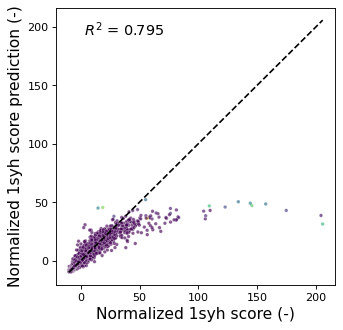

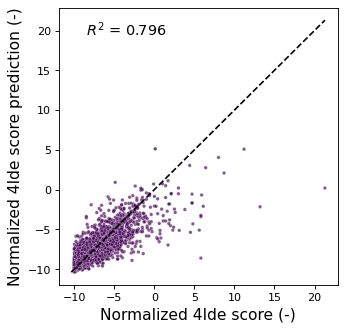

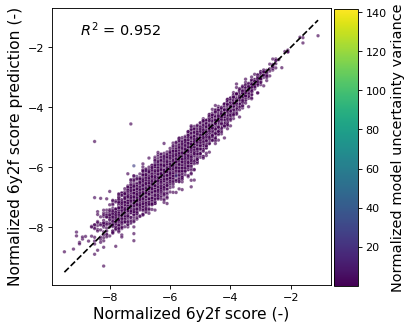

In [3]:
scaler_dict = {"1syh score": (-2.832, 8.928), "4lde score": (-7.547, 1.617), "6y2f score": (-5.528, 0.997)}
target_columns = ["1syh score", "4lde score", "6y2f score"]
model_path = "chemprop_unc/save_models/docking/evidential/fold_0"
dataset = "docking"

data = create_data(model_path, target_columns, scaler_dict, normalize_data=False)
create_unc_plot(data, target_columns, dataset)


RMSE, MAE, R2 score
0.441, 0.120, 0.795
RMSE, MAE, R2 score
0.441, 0.215, 0.796
RMSE, MAE, R2 score
0.218, 0.160, 0.952


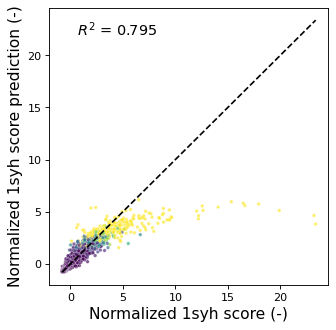

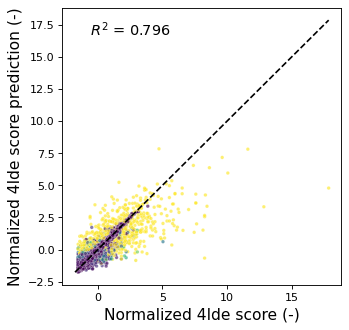

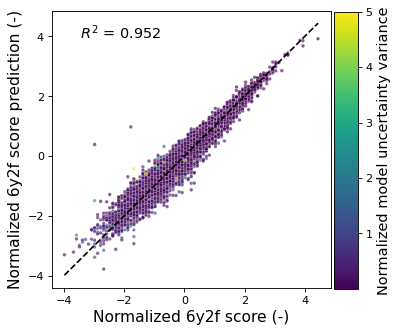

In [4]:
scaler_dict = {"1syh score": (-2.832, 8.928), "4lde score": (-7.547, 1.617), "6y2f score": (-5.528, 0.997)}
target_columns = ["1syh score", "4lde score", "6y2f score"]
model_path = "chemprop_unc/save_models/docking/evidential/fold_0"
dataset = "docking"
trunc_values = (5, 5, 5)

data = create_data(model_path, target_columns, scaler_dict)
data_new = truncate_unc(data, target_columns, trunc_values)
create_unc_plot(data_new, target_columns, dataset)



## Organic Emitters

RMSE, MAE, R2 score
0.117, 0.075, 0.912
RMSE, MAE, R2 score
0.068, 0.031, 0.784
RMSE, MAE, R2 score
0.316, 0.200, 0.907


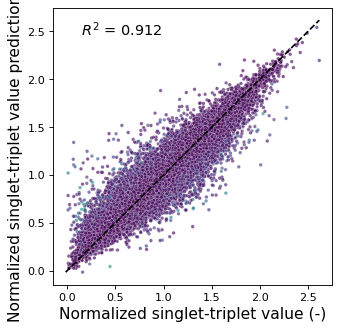

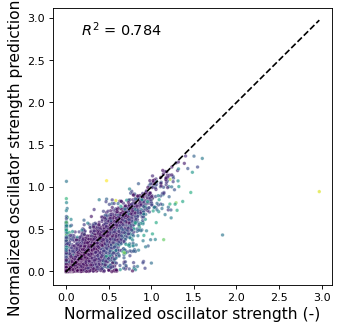

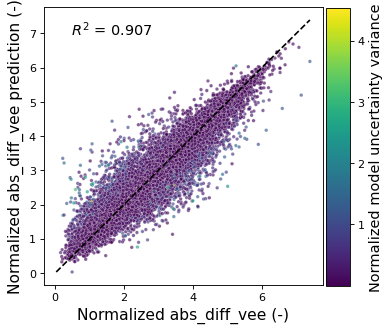

In [5]:
scaler_dict = {"singlet-triplet value": (1.003, 0.396), "oscillator strength": (0.086, 0.149), "abs_diff_vee": (2.688, 1.038)}
target_columns = ["singlet-triplet value", "oscillator strength", "abs_diff_vee"]
model_path = "chemprop_unc/save_models/organic_emitter/ensemble_mve/fold_0"
dataset = "organic_emitter"

data = create_data(model_path, target_columns, scaler_dict, uncertainty_method="mve", normalize_data=False)
create_unc_plot(data, target_columns, dataset, uncertainty_method="mve")


RMSE, MAE, R2 score
0.117, 0.075, 0.912
RMSE, MAE, R2 score
0.068, 0.031, 0.784
RMSE, MAE, R2 score
0.316, 0.200, 0.907


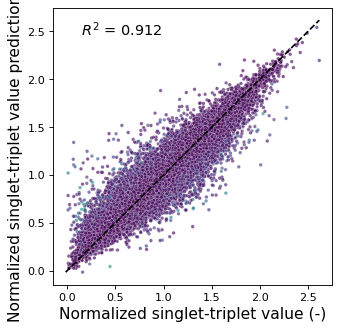

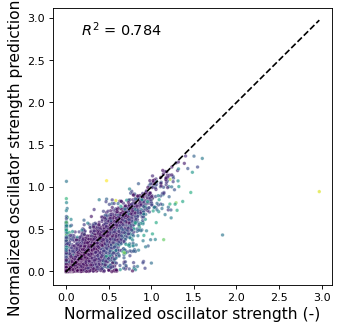

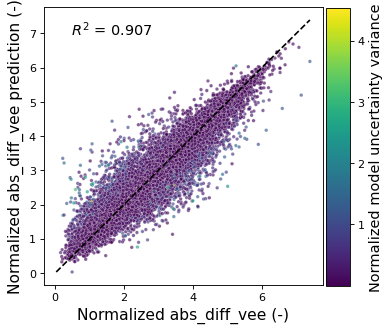

In [6]:
trunc_values = (5, 5, 5)
data_new = truncate_unc(data, target_columns, trunc_values,uncertainty_method="mve")
create_unc_plot(data_new, target_columns, dataset, uncertainty_method="mve")

## Reactivity

RMSE, MAE, R2 score
0.473, 0.350, 0.772
RMSE, MAE, R2 score
0.226, 0.145, 0.947


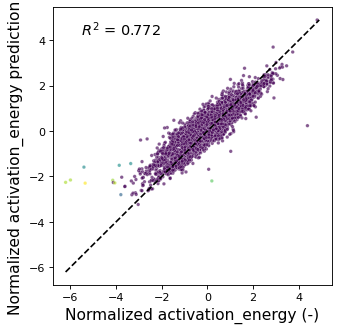

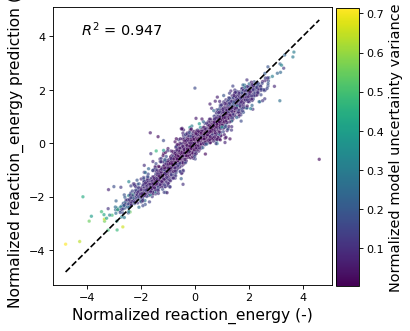

In [7]:
scaler_dict = {"activation_energy": (84.104, 3.076), "reaction_energy": (-0.749, 4.507)}
target_columns = ["activation_energy", "reaction_energy"]
model_path = "chemprop_unc/save_models/reactivity/evidential_final/fold_0"
dataset = "reactivity"

data = create_data(model_path, target_columns, scaler_dict, uncertainty_method="evidential_total")
trunc_values = (5, 5, 5)
create_unc_plot(data, target_columns, dataset, uncertainty_method="evidential_total")


## Plot cutoff-based scalarization

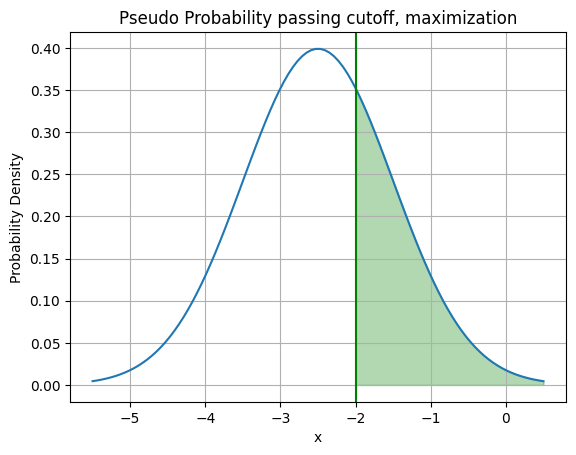

0.3085375387259869


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_gaussian_distribution(mean, std, cutoff=None, greater_than=True, title=None):
    x = np.linspace(mean - 3*std, mean + 3*std, 100)
    y = (1/(std * np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mean)/std)**2)

    plt.plot(x, y)

    if cutoff is not None:
        plt.axvline(cutoff, color='g')  

        if greater_than:
            fill_x = np.linspace(cutoff, mean + 3*std, 100)
            fill_y = (1/(std * np.sqrt(2*np.pi))) * np.exp(-0.5*((fill_x-mean)/std)**2)
            plt.fill_between(fill_x, fill_y, color='green', alpha=0.3)
        else:
            fill_x = np.linspace(mean - 3*std, cutoff, 100)
            fill_y = (1/(std * np.sqrt(2*np.pi))) * np.exp(-0.5*((fill_x-mean)/std)**2)
            plt.fill_between(fill_x, fill_y, color='green', alpha=0.3)

    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('Probability Density')
    plt.grid(True)
    plt.show()

def calculate_greater_cdf(cutoff, mean, std):
    '''
    Calculate the cumulative distribution greater than a certain cutoff,
    that is, the probability greater than a certain cutoff
    '''
    return 1 - norm.cdf(cutoff, loc=mean, scale=std)

def calculate_less_cdf(cutoff, mean, std): 
    '''
    Calculate the cumulative distribution smaller than a certain cutoff, that is, 
    the probability of being smaller than a certain cutoff
    '''
    return norm.cdf(cutoff, loc=mean, scale=std)

# test the code
mean = -2.5   
std = 1.
cutoff = -2 
greater_than = True
title = "Pseudo Probability passing cutoff, maximization"

plot_gaussian_distribution(mean, std, cutoff, greater_than=greater_than, title=title)
if greater_than:
    print(calculate_greater_cdf(cutoff, mean, std))
else:
    print(calculate_less_cdf(cutoff, mean, std))

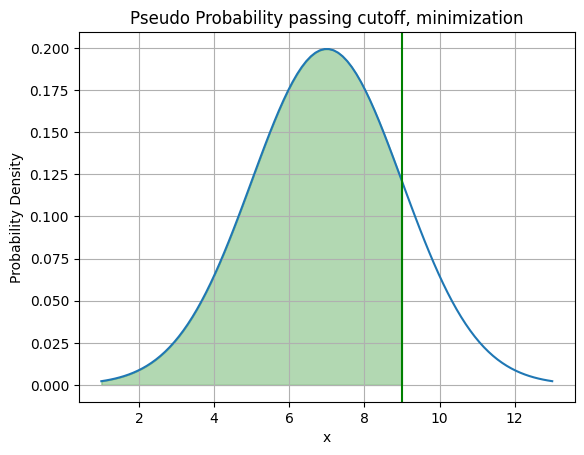

0.8413447460685429


In [14]:
# 測試程式碼
mean = 7   # 平均值
std = 2.   # 標準差
cutoff = 9  # 截斷值
greater_than = False  # 大於cutoff的區域為紅色塗色
title = "Pseudo Probability passing cutoff, minimization"

plot_gaussian_distribution(mean, std, cutoff, greater_than=greater_than, title=title)
if greater_than:
    print(calculate_greater_cdf(cutoff, mean, std))
else:
    print(calculate_less_cdf(cutoff, mean, std))